# Load spatialdata object

In [4]:
import anndata as ad
import spatialdata as sd
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
from pathlib import Path
from fitter import Fitter
import scipy.stats as stats
import numpy as np


# Add the folder two levels up to Python path
sys.path.append('../../src/sprot/aggregating')

# Now you can import your package
from aggregate import *
from plot import *
from compute import *

sys.path.append('../../src/sprot/metrics')
sys.path.append('../../src/sprot/pl')
sys.path.append('../../src/sprot/utils')

from protein_contribution import *
from protein_properties import *
from technical_correction import *
from protein_quality_metrics import *
from visualization import *
from utils import *


We read the MIBI-tof data. We use spatialdata readers for this

In [2]:
sdata=sd.read_zarr('/Users/sergio/Documents/jnotebooks/sprot_hackathon/data/cycif.zarr')

/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


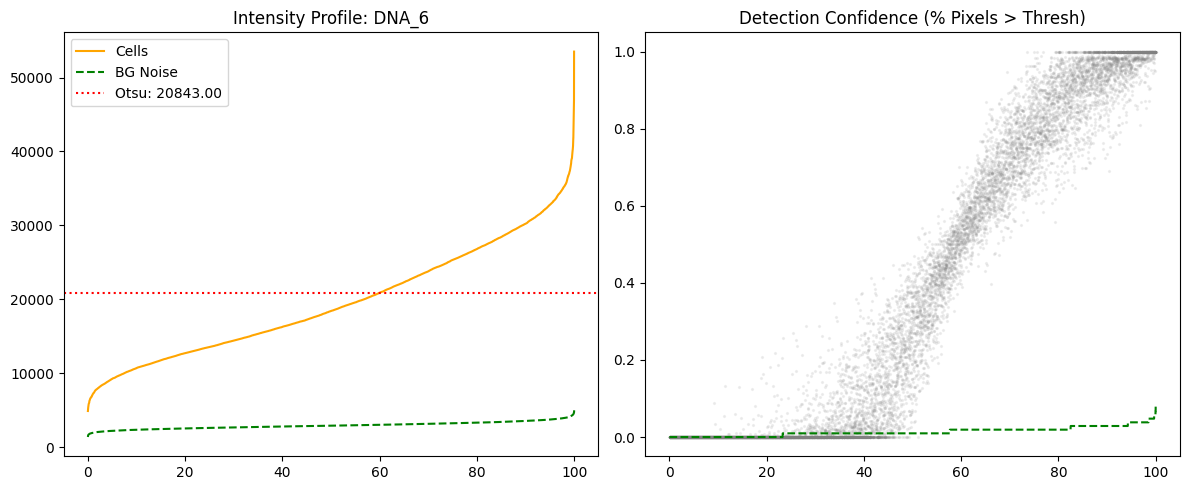

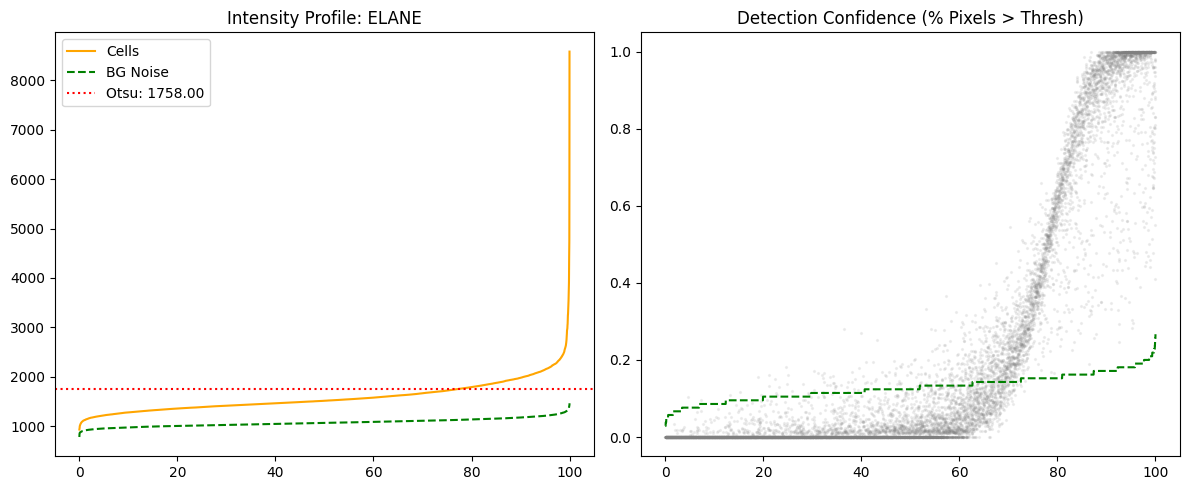

In [5]:
img_key = 'exemplar-001_image'
label_key = 'exemplar-001_cell'
summary = []

for protein in sdata[img_key].c.values[0:2]:
    # 1. Threshold first (Independent function)
    otsu_val = calculate_otsu_threshold(sdata, img_key, label_key, protein)
    
    # 2. Call metrics (Each takes sdata as input)
    gini = metric_sparsity_gini(sdata, img_key, label_key, protein)
    sni = metric_rel_sni(sdata, img_key, label_key, protein, thresh=otsu_val)
    cov = metric_intracell_coverage(sdata, img_key, label_key, protein, thresh=otsu_val)
    
    summary.append({
        'Protein': protein,
        'Gini': round(gini, 3),
        'SNI': round(sni, 2),
        'Coverage': round(cov, 3)})
    
    # 3. Plotting
    df_c, df_b = get_processed_distributions(sdata, img_key, label_key, protein, otsu_val)
    plot_diagnostic_curves(df_c, df_b, protein, otsu_val)

df_results = pd.DataFrame(summary)

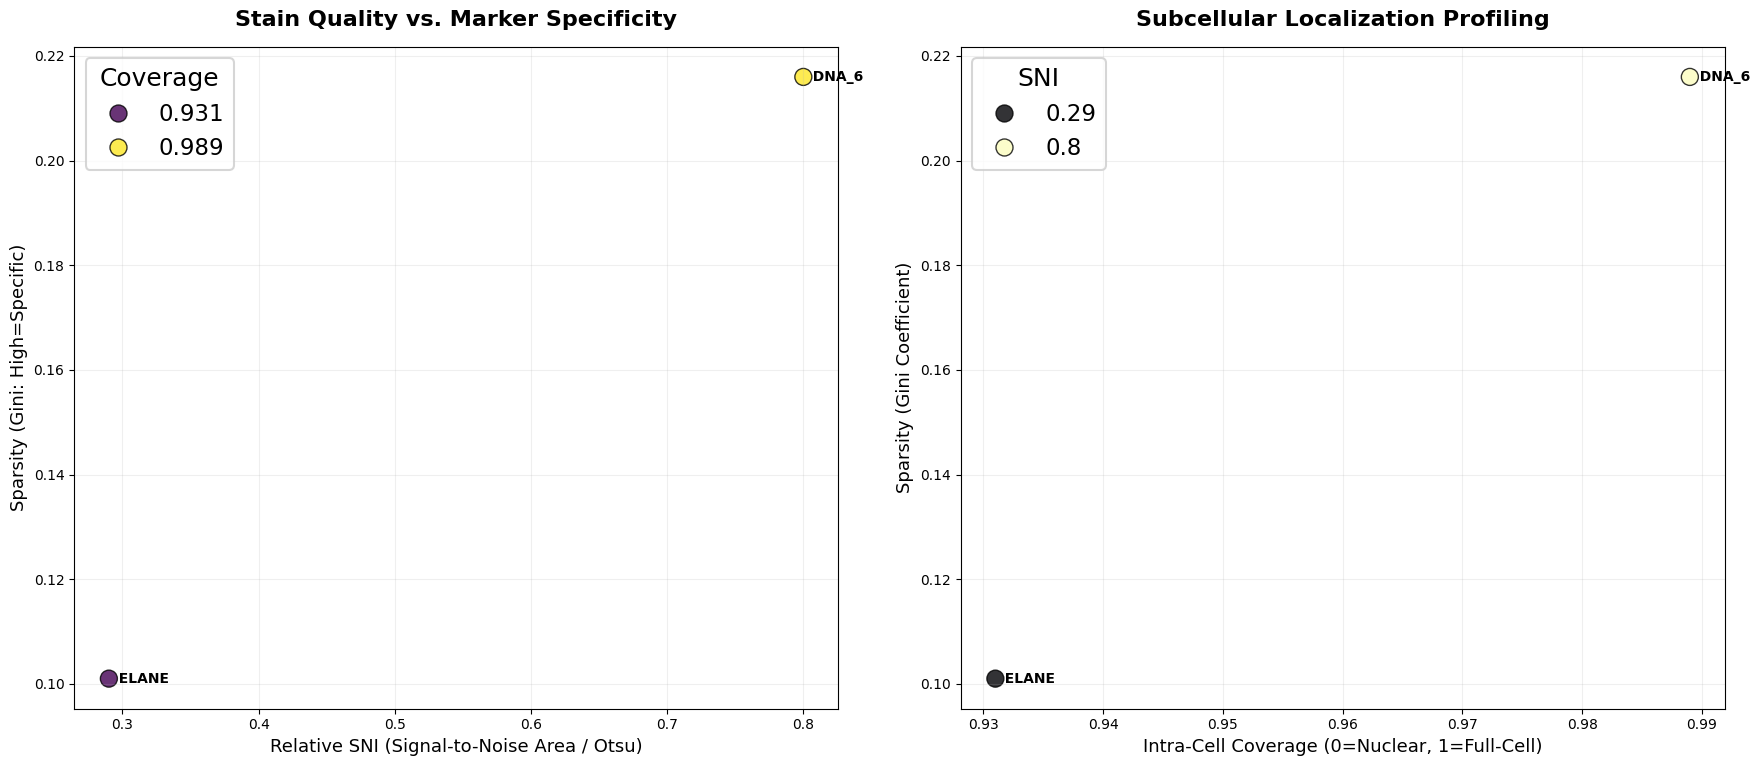

In [6]:
# Initialize the layout
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Call 1: Stain Quality vs Specificity
plot_protein_scatter(
    df=df_results, 
    x='SNI', 
    y='Gini', 
    hue='Coverage',
    title='Stain Quality vs. Marker Specificity',
    xlabel='Relative SNI (Signal-to-Noise Area / Otsu)',
    ylabel='Sparsity (Gini: High=Specific)',
    palette='viridis',
    ax=axes[0]
)

# Call 2: Subcellular Localization Profiling
plot_protein_scatter(
    df=df_results, 
    x='Coverage', 
    y='Gini', 
    hue='SNI',
    title='Subcellular Localization Profiling',
    xlabel='Intra-Cell Coverage (0=Nuclear, 1=Full-Cell)',
    ylabel='Sparsity (Gini Coefficient)',
    palette='magma',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

To extract single-value metrics from the data we've generated, we can look at the distribution of the "Cell Rank vs. Proportion" and "Intensity vs. Noise" curves.

Here are three mathematical metrics that represent your specific biological questions:

- 1. Bimodality / Sparsity (Expression Heterogeneity)

        - Goal: Determine if a protein is expressed in a specific subset (like FOXP3) or is generally "on" across the tissue (like DAPI).

        - Metric: Gini Coefficient of Mean Intensity

        - How it works: The Gini coefficient measures inequality.

        - A value near 0 means every cell has roughly the same intensity (homogeneous expression).

        - A value near 1 means only a tiny fraction of cells are bright, while most are dark (high sparsity/target specificity).
        - Alternative: Delta-Rank (90th vs 10th percentile). If the 90th percentile intensity is >10x the 10th percentile, it is highly specific.

- 2. Extracellular / Background Fraction

        - Goal: Determine to what degree a protein is "leaking" out of cells or is non-specific.

        - Metric: Signal-to-Noise Integral (SNI)

        - How it works: Calculate the area between the Orange Line (Cell Intensity) and the Green Line (Background Intensity) in your first plot.SNI=∫ 0 100
(Cell Intensity 
p
​	
 −Background Intensity 
p
​	
 )dp
Interpretation: * High SNI: The protein is strictly contained within cells.

        -Low SNI: The protein intensity inside cells is nearly identical to the intensity outside cells, suggesting a high degree of extracellular/non-specific signal.

- 3. Intra-cellular Coverage (Sub-cellularity)

        - Goal: Determine if a protein covers all pixels (cytoplasmic/membrane) or just a subset (punctuated/nuclear).

        - Metric: Mean Proportion Positive (Top 5% of cells)

        - How it works: Take only the top 5% brightest cells (the "True Positives") and look at their prop_positive values. Interpretation: * Value ~ 1.0: The protein is expressed in every pixel of the cell (e.g., a pan-membrane marker like CD45). Value < 0.3: Even in the brightest cells, only a small part of the cell is positive (e.g., a nuclear marker like FOXP3 or a granular organelle marker).

We can extract image info using

/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)
/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)
/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)
100%|██████████| 12/12 [00:09<00:00,  1.27it/s]


# now we expand cells

In [131]:
import numpy as np
from skimage.segmentation import expand_labels
from spatialdata.models import Labels2DModel
from spatialdata.transformations import get_transformation

def expand_nuclei_to_cells(sdata, nuclei_key, distance=10, new_key='expanded_cells'):
    """
    Expands nuclei labels by a fixed distance to create a new label layer.
    """
    # 1. Get the original labels (assuming 2D for this example)
    # .values gets the dask/numpy array, .compute() ensures it's in memory for skimage
    nuclei_labels = sdata[nuclei_key].values
    
    # 2. Perform expansion (distance is in pixels)
    expanded_labels = expand_labels(nuclei_labels, distance=distance)
    
    # 3. Create the new SpatialData element
    # We copy the transformation from the original nuclei to ensure alignment
    transform = get_transformation(sdata[nuclei_key], get_all=True)
    
    sdata[new_key] = Labels2DModel.parse(
        expanded_labels, 
        transformations=transform
    )
    
    print(f"Added new layer '{new_key}' expanded by {distance}px.")
    return sdata

# Example usage:
sdata = expand_nuclei_to_cells(sdata, 'exemplar-001_nuclei', distance=10)

INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                
Added new layer 'expanded_cells' expanded by 10px.


/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/spatialdata/_core/_elements.py:91: UserWarning: Key `expanded_cells` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


# We apply to cells

In [132]:
# --- Main Execution Loop ---
img_key = 'exemplar-001_image'
label_key = 'expanded_cells'
proteins = sdata[img_key].c.values

summary_list = []

for protein in proteins:
    try:
        # 1. Generate distributions
        df_c, df_b, thresh = get_pixel_stats_auto(sdata, img_key, label_key, protein, plot=False)
        #plot_roi_aligned(sdata, img_key, label_key, protein, x_range=(600, 1000), y_range=(600, 1000))
        # 2. Calculate SNI and other metrics
        m = calculate_comparable_metrics(df_c, df_b,thresh, protein)
        summary_list.append(m)
        
        print(f"{protein} -> SNI: {m['Rel_SNI']} | Gini: {m['Sparsity_Gini']}")
        
    except Exception as e:
        print(f"Error on {protein}: {e}")

# --- Final Summary ---
df_summary = pd.DataFrame(summary_list).sort_values('Rel_SNI', ascending=False)
print(df_summary)

DNA_6 -> SNI: 0.77 | Gini: 0.261
ELANE -> SNI: 0.25 | Gini: 0.113
CD57 -> SNI: 0.04 | Gini: 0.736
CD45 -> SNI: 0.51 | Gini: 0.352
DNA_7 -> SNI: 0.78 | Gini: 0.262
CD11B -> SNI: 0.39 | Gini: 0.165
SMA -> SNI: 0.29 | Gini: 0.375
CD16 -> SNI: 0.17 | Gini: 0.309
DNA_8 -> SNI: 0.76 | Gini: 0.267
ECAD -> SNI: 0.36 | Gini: 0.28
FOXP3 -> SNI: 0.1 | Gini: 0.272
NCAM -> SNI: 0.07 | Gini: 0.034
   Protein  Sparsity_Gini  Rel_SNI  IntraCell_Coverage
4    DNA_7          0.262     0.78               0.875
0    DNA_6          0.261     0.77               0.875
8    DNA_8          0.267     0.76               0.861
3     CD45          0.352     0.51               0.908
5    CD11B          0.165     0.39               0.549
9     ECAD          0.280     0.36               0.678
6      SMA          0.375     0.29               0.611
1    ELANE          0.113     0.25               0.136
7     CD16          0.309     0.17               0.548
10   FOXP3          0.272     0.10               0.231
11    NC

In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add a 'Type' column to distinguish the runs
df_summary_nuclei['Segmentation'] = 'Nuclei'
df_summary['Segmentation'] = 'Whole-Cell'

# Combine into one master comparison dataframe
df_compare = pd.concat([df_summary_nuclei, df_summary], axis=0).reset_index(drop=True)

We plot it

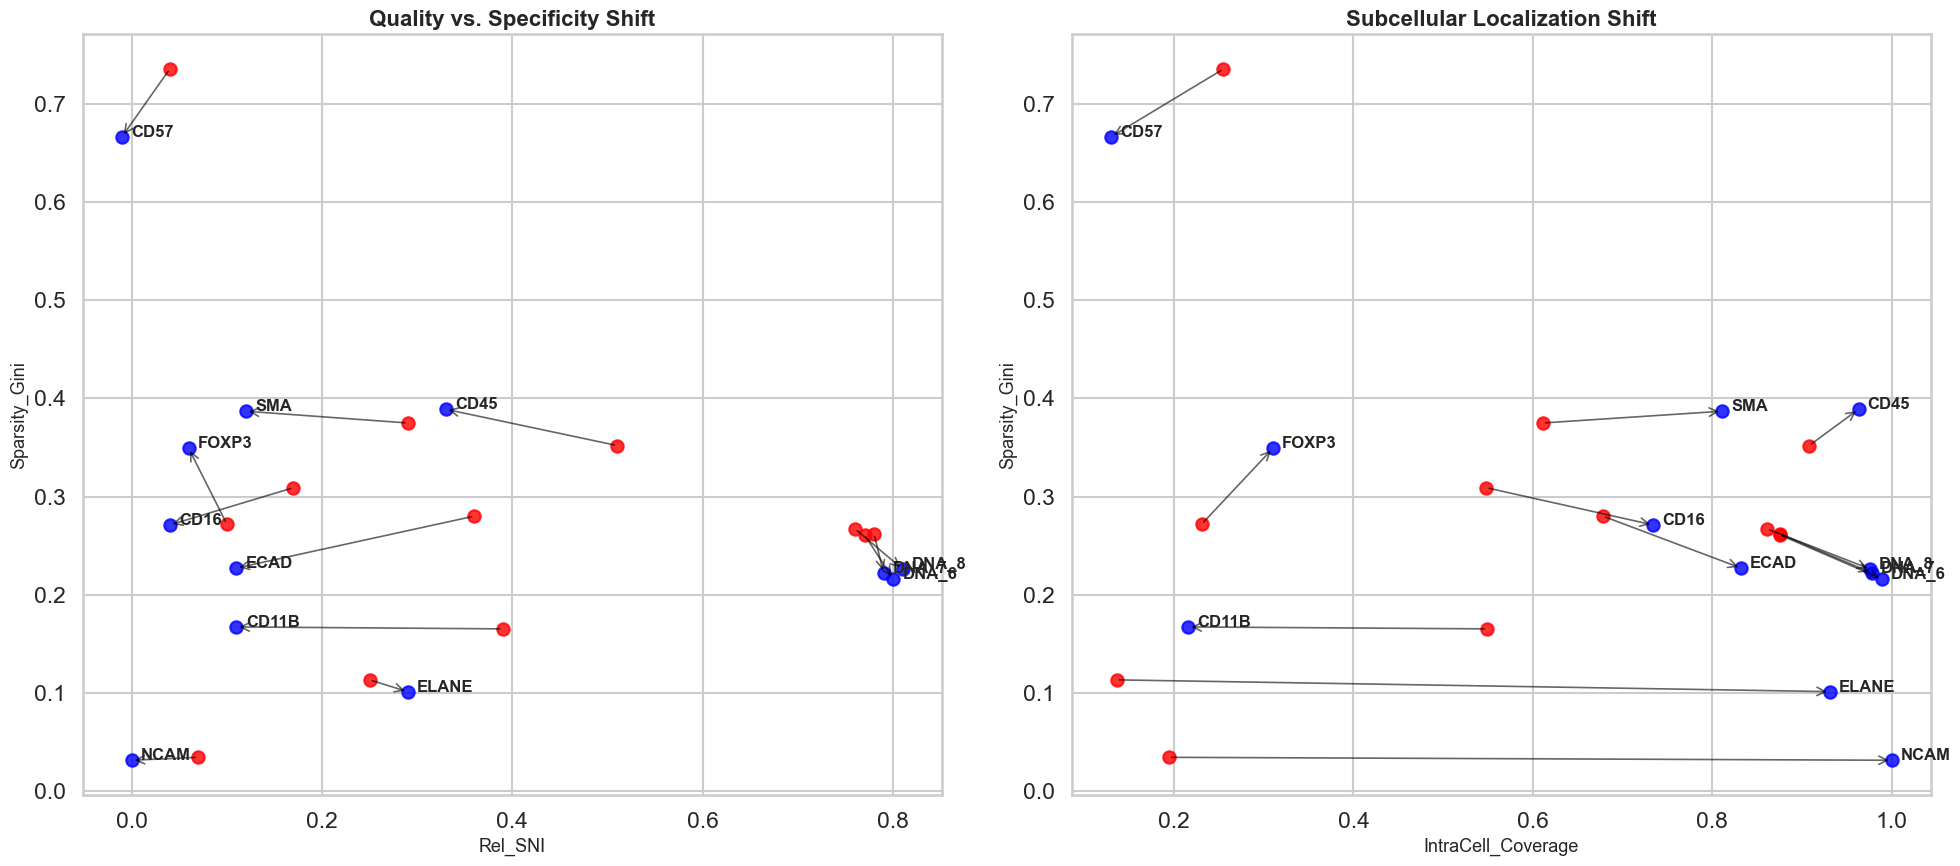

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_paired_segmentation_shift(df_cells, df_nuclei):
    """
    Plots the shift in metrics between Whole-Cell and Nuclei segmentation.
    Arrows point from Whole-Cell -> Nuclei.
    """
    # 1. Prepare Data
    df_cells = df_cells.copy()
    df_nuclei = df_nuclei.copy()
    
    # Ensure they are aligned by Protein name
    common_proteins = np.intersect1d(df_cells.Protein, df_nuclei.Protein)
    df_c = df_cells[df_cells.Protein.isin(common_proteins)].set_index('Protein').loc[common_proteins]
    df_n = df_nuclei[df_nuclei.Protein.isin(common_proteins)].set_index('Protein').loc[common_proteins]

    fig, ax = plt.subplots(1, 2, figsize=(20, 9))
    sns.set_style("whitegrid")

    # Metrics to plot
    pairs = [
        ('Rel_SNI', 'Sparsity_Gini', ax[0], 'Quality vs. Specificity Shift'),
        ('IntraCell_Coverage', 'Sparsity_Gini', ax[1], 'Subcellular Localization Shift')
    ]

    for x_col, y_col, plot_ax, title in pairs:
        # Plot the start points (Cells) and end points (Nuclei)
        plot_ax.scatter(df_c[x_col], df_c[y_col], color='red', alpha=0.8, s=80, label='Whole-Cell')
        plot_ax.scatter(df_n[x_col], df_n[y_col], color='blue', alpha=0.8, s=80, label='Nuclei')

        # Draw Arrows for each protein
        for protein in common_proteins:
            x_start, y_start = df_c.loc[protein, x_col], df_c.loc[protein, y_col]
            x_end, y_end = df_n.loc[protein, x_col], df_n.loc[protein, y_col]
            
            # Draw the arrow
            plot_ax.annotate("", 
                             xy=(x_end, y_end), 
                             xytext=(x_start, y_start),
                             arrowprops=dict(arrowstyle="->", color="black", lw=1.2, alpha=0.6, mutation_scale=15))
            
            # Label the end point (Nuclei)
            plot_ax.text(x_end + 0.01, y_end, protein, fontsize=12, fontweight='bold')

        plot_ax.set_title(title, fontsize=16, fontweight='bold')
        plot_ax.set_xlabel(x_col, fontsize=13)
        plot_ax.set_ylabel(y_col, fontsize=13)

    plt.tight_layout()
    plt.show()

# --- Run the Comparison ---
plot_paired_segmentation_shift(df_summary, df_summary_nuclei)

In [114]:
df_compare

,Protein,Sparsity_Gini,Rel_SNI,IntraCell_Coverage,Segmentation
0,DNA_8,0.226,0.81,0.976,Nuclei
1,DNA_6,0.216,0.80,0.989,Nuclei
2,DNA_7,0.222,0.79,0.978,Nuclei
3,CD45,0.389,0.33,0.963,Nuclei
4,ELANE,0.101,0.29,0.931,Nuclei
5,SMA,0.387,0.12,0.811,Nuclei
6,CD11B,0.167,0.11,0.216,Nuclei
7,ECAD,0.227,0.11,0.832,Nuclei
8,FOXP3,0.349,0.06,0.310,Nuclei
9,CD16,0.271,0.04,0.734,Nuclei


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.segmentation import find_boundaries

def plot_segmentation_mask_comparison(sdata, image_key, cell_key, nuclei_key, 
                                      dna_channel='DNA_7', cols=3, 
                                      x_range=(700, 950), y_range=(700, 950)):
    """
    Plots a grid of ROIs showing:
    - Background: DAPI/DNA signal (gray)
    - Cyan Outlines: Whole-Cell Segmentation ('exemplar-001_cell')
    - Red Outlines: Nuclei Segmentation ('exemplar-001_nuclei')
    """
    # Slice ROI coordinates
    roi_slice = (slice(y_range[0], y_range[1]), slice(x_range[0], x_range[1]))
    
    # 1. Extract Data
    dna_img = sdata[image_key].sel(c=dna_channel).values.squeeze()[roi_slice]
    cell_mask = sdata[cell_key].values.squeeze()[roi_slice]
    nuclei_mask = sdata[nuclei_key].values.squeeze()[roi_slice]
    
    # 2. Contrast scaling for DNA background
    p1, p99 = np.percentile(dna_img, (1, 99.5))
    dna_rescaled = np.clip((dna_img - p1) / (p99 - p1 + 1e-5), 0, 1)
    
    # 3. Create Outlines
    cell_bounds = find_boundaries(cell_mask, mode='inner')
    nuclei_bounds = find_boundaries(nuclei_mask, mode='inner')
    
    # Create RGBA overlays
    # Cell = Cyan (0, 1, 1)
    cell_rgba = np.zeros((*cell_bounds.shape, 4))
    cell_rgba[cell_bounds] = [0, 1, 1, 1] 
    
    # Nuclei = Red (1, 0, 0)
    nuclei_rgba = np.zeros((*nuclei_bounds.shape, 4))
    nuclei_rgba[nuclei_bounds] = [1, 0, 0, 1]

    # --- Plotting ---
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    
    # Show DNA
    ax.imshow(dna_rescaled, cmap='gray')
    
    # Show Whole-Cell (Cyan)
    ax.imshow(cell_rgba, interpolation='nearest', label='Whole-Cell')
    
    # Show Nuclei (Red)
    ax.imshow(nuclei_rgba, interpolation='nearest', label='Nuclei')
    
    ax.set_title(f"Segmentation Comparison\nCyan: Whole-Cell | Red: Nuclei\nBase: {dna_channel}", 
                 fontsize=14, fontweight='bold')
    ax.axis('off')

    # Add a custom legend
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='cyan', lw=2),
                    Line2D([0], [0], color='red', lw=2)]
    ax.legend(custom_lines, ['Whole-Cell', 'Nuclei'], loc='upper right', frameon=True)

    plt.tight_layout()
    plt.show()

# --- Run Visual Comparison ---
plot_segmentation_mask_comparison(
    sdata, 
    'exemplar-001_image', 
    'expanded_cells', 
    'exemplar-001_nuclei', 
    dna_channel='DNA_7', 
    x_range=(750, 900), 
    y_range=(750, 900)
)

INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                
Added new layer 'expanded_cells' expanded by 5px.


/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/spatialdata/_core/_elements.py:91: UserWarning: Key `expanded_cells` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


<xarray.DataArray 'image' (y: 3139, x: 2511)> Size: 32MB
dask.array<array, shape=(3139, 2511), dtype=int32, chunksize=(3139, 2511), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 25kB 0.5 1.5 2.5 3.5 ... 3.136e+03 3.138e+03 3.138e+03
  * x        (x) float64 20kB 0.5 1.5 2.5 3.5 ... 2.508e+03 2.51e+03 2.51e+03
Attributes:
    transform:  {'global': Identity }